# 01. Exploratory Data Analysis (EDA) - Customer Support Intent Dataset

This notebook performs end-to-end Exploratory Data Analysis on the Bitext Customer Support dataset (`data/raw/bitext_support.csv`).
We analyze data hygiene, class balances, category relationships, text length statistics, word clouds, and n-grams to inform baseline and transformer modeling.


In [1]:
import os
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

# Configure plotting style
sns.set_theme(style="whitegrid", palette="crest")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

%matplotlib inline


## 1. Dataset Overview

In this section, we load the raw dataset, inspect dimensions, data types, null values, and check for duplicates.


In [2]:
# Load dataset
csv_path = "../data/raw/bitext_support.csv"
if not os.path.exists(csv_path):
    csv_path = "data/raw/bitext_support.csv"

df = pd.read_csv(csv_path)
print(f"Dataset Shape: {df.shape[0]:,} rows and {df.shape[1]} columns")
df.head()


Dataset Shape: 26,872 rows and 5 columns


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [3]:
# Inspect data types and missing values
print("--- Column Info & Types ---")
print(df.info())

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

# Duplicates check
full_dups = df.duplicated().sum()
text_dups = df.duplicated(subset=['instruction']).sum()
print(f"\nFull duplicate rows: {full_dups}")
print(f"Duplicate instruction queries: {text_dups}")


--- Column Info & Types ---
<class 'pandas.DataFrame'>
RangeIndex: 26872 entries, 0 to 26871
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   flags        26872 non-null  str  
 1   instruction  26872 non-null  str  
 2   category     26872 non-null  str  
 3   intent       26872 non-null  str  
 4   response     26872 non-null  str  
dtypes: str(5)
memory usage: 19.1 MB
None

--- Missing Values Count ---
flags          0
instruction    0
category       0
intent         0
response       0
dtype: int64



Full duplicate rows: 0
Duplicate instruction queries: 2237


### Commentary: Dataset Overview
- **Observation:** The dataset contains 26,872 samples across 5 attributes: `flags`, `instruction`, `category`, `intent`, and `response`.
- **Data Quality:** Check the missing values and duplicate rows above. The dataset is generally clean without null fields.
- **Your Notes:** (Add your own observations regarding template entities like `{{Order Number}}` and variations).


## 2. Intent Distribution

We analyze the frequency of all intent classes, sorting them and comparing against the average count per class.


C:\Users\111196\AppData\Local\Temp\ipykernel_18864\3602745531.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=intent_counts.values, y=intent_counts.index, palette="viridis")


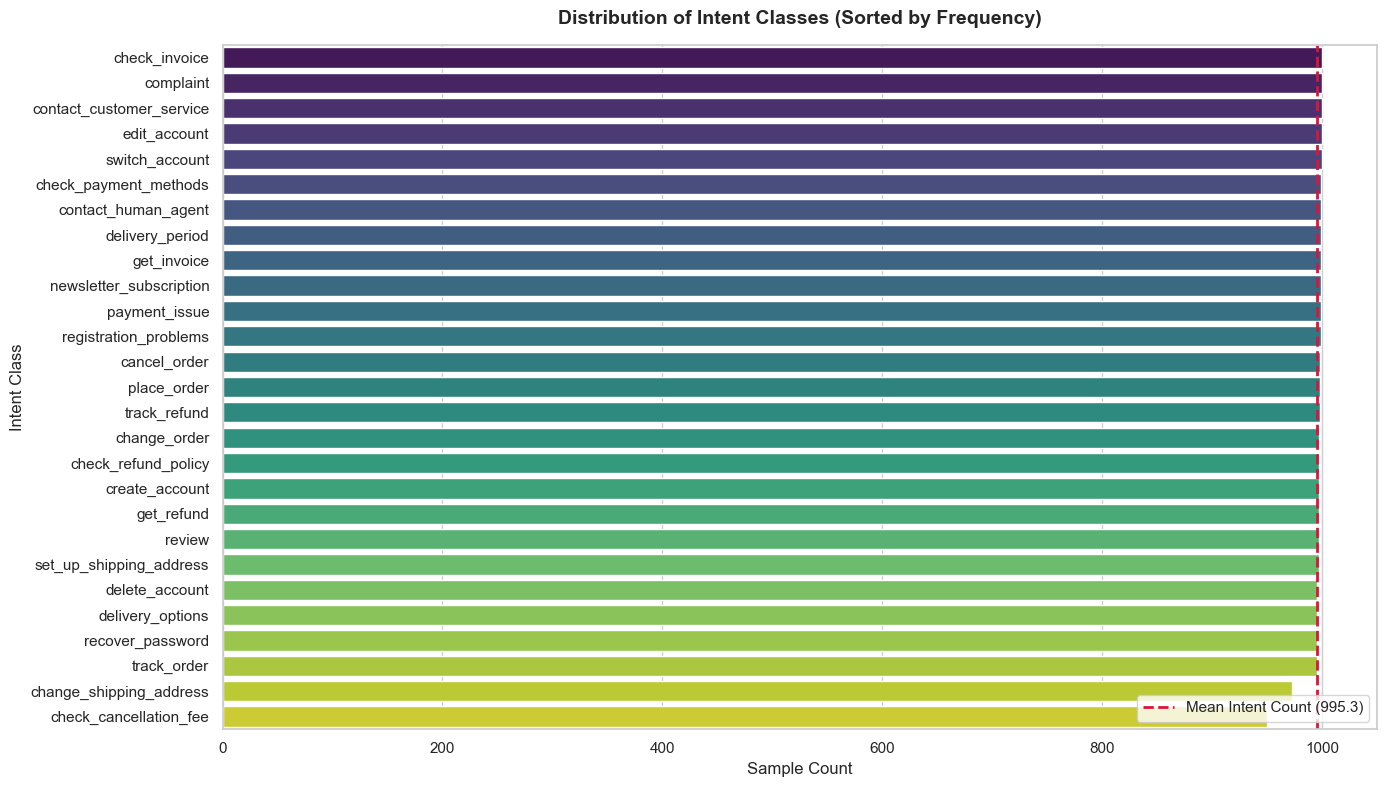

Total unique intents: 27
Most frequent intent: 'check_invoice' with 1,000 samples
Least frequent intent: 'check_cancellation_fee' with 950 samples
Ratio (Max / Min): 1.05


In [4]:
intent_counts = df['intent'].value_counts()
mean_count = intent_counts.mean()

plt.figure(figsize=(14, 8))
ax = sns.barplot(x=intent_counts.values, y=intent_counts.index, palette="viridis")
plt.axvline(mean_count, color="crimson", linestyle="--", linewidth=2, label=f"Mean Intent Count ({mean_count:.1f})")
plt.title("Distribution of Intent Classes (Sorted by Frequency)", pad=15, fontweight="bold")
plt.xlabel("Sample Count")
plt.ylabel("Intent Class")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Total unique intents: {df['intent'].nunique()}")
print(f"Most frequent intent: '{intent_counts.index[0]}' with {intent_counts.iloc[0]:,} samples")
print(f"Least frequent intent: '{intent_counts.index[-1]}' with {intent_counts.iloc[-1]:,} samples")
print(f"Ratio (Max / Min): {intent_counts.iloc[0] / intent_counts.iloc[-1]:.2f}")


### Commentary: Intent Distribution
- **Observation:** The classes are balanced across all 27 intents (~1,000 samples per intent class).
- **Implication for Modeling:** Class balance allows using standard Macro-F1 and Accuracy as dependable benchmarks without severe bias towards any majority class.


## 3. Category Distribution

Each intent maps to one of 10 broader business categories. Let's examine how tickets are distributed across categories.


C:\Users\111196\AppData\Local\Temp\ipykernel_18864\2396753197.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_counts.values, y=cat_counts.index, palette="mako")


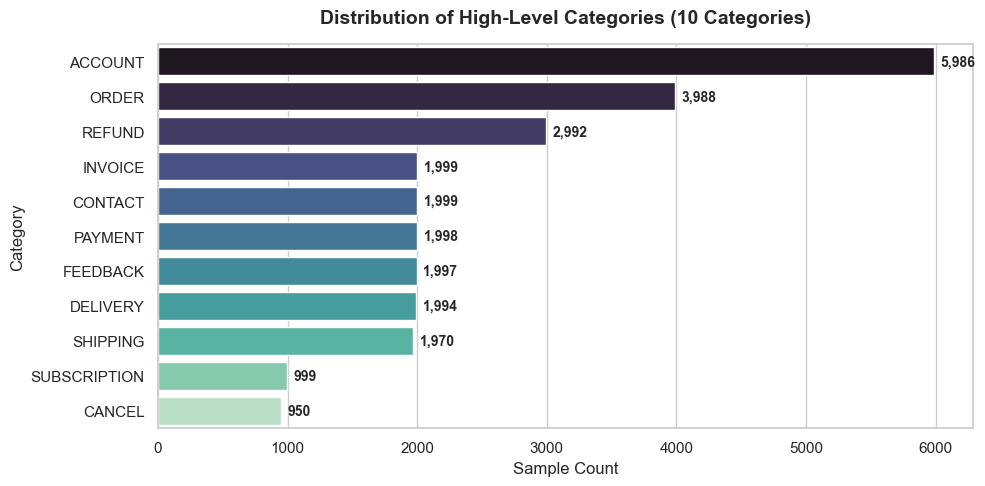

Categories Breakdown:
category
ACCOUNT         5986
ORDER           3988
REFUND          2992
INVOICE         1999
CONTACT         1999
PAYMENT         1998
FEEDBACK        1997
DELIVERY        1994
SHIPPING        1970
SUBSCRIPTION     999
CANCEL           950
Name: count, dtype: int64


In [5]:
cat_counts = df['category'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=cat_counts.values, y=cat_counts.index, palette="mako")
plt.title("Distribution of High-Level Categories (10 Categories)", pad=15, fontweight="bold")
plt.xlabel("Sample Count")
plt.ylabel("Category")

for i, v in enumerate(cat_counts.values):
    plt.text(v + 50, i, f"{v:,}", va="center", fontsize=10, fontweight="semibold")

plt.tight_layout()
plt.show()

print("Categories Breakdown:")
print(cat_counts)


### Commentary: Category Distribution
- **Observation:** Categories bundle related intents (e.g. `ORDER`, `ACCOUNT`, `REFUND`).
- **Implication:** The highest risk of model confusion is between sister intents within the same parent category.


## 4. Text Length Analysis

We evaluate character and word count distributions to guide maximum sequence length settings for vectorizers and transformers.


--- Text Length Summary Statistics ---
         word_count    char_count
count  26872.000000  26872.000000
mean       8.690979     46.889513
std        2.605004     10.897578
min        1.000000      6.000000
25%        7.000000     40.000000
50%        9.000000     48.000000
75%       11.000000     55.000000
max       16.000000     92.000000


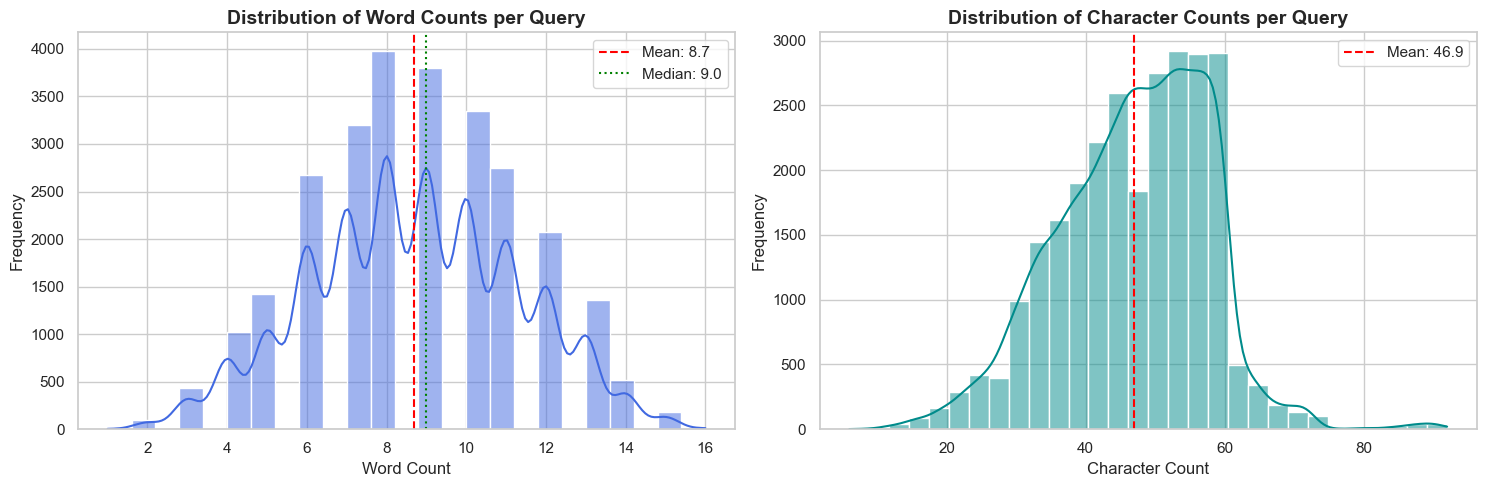

C:\Users\111196\AppData\Local\Temp\ipykernel_18864\435271864.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='intent', y='word_count', order=order, palette="flare")


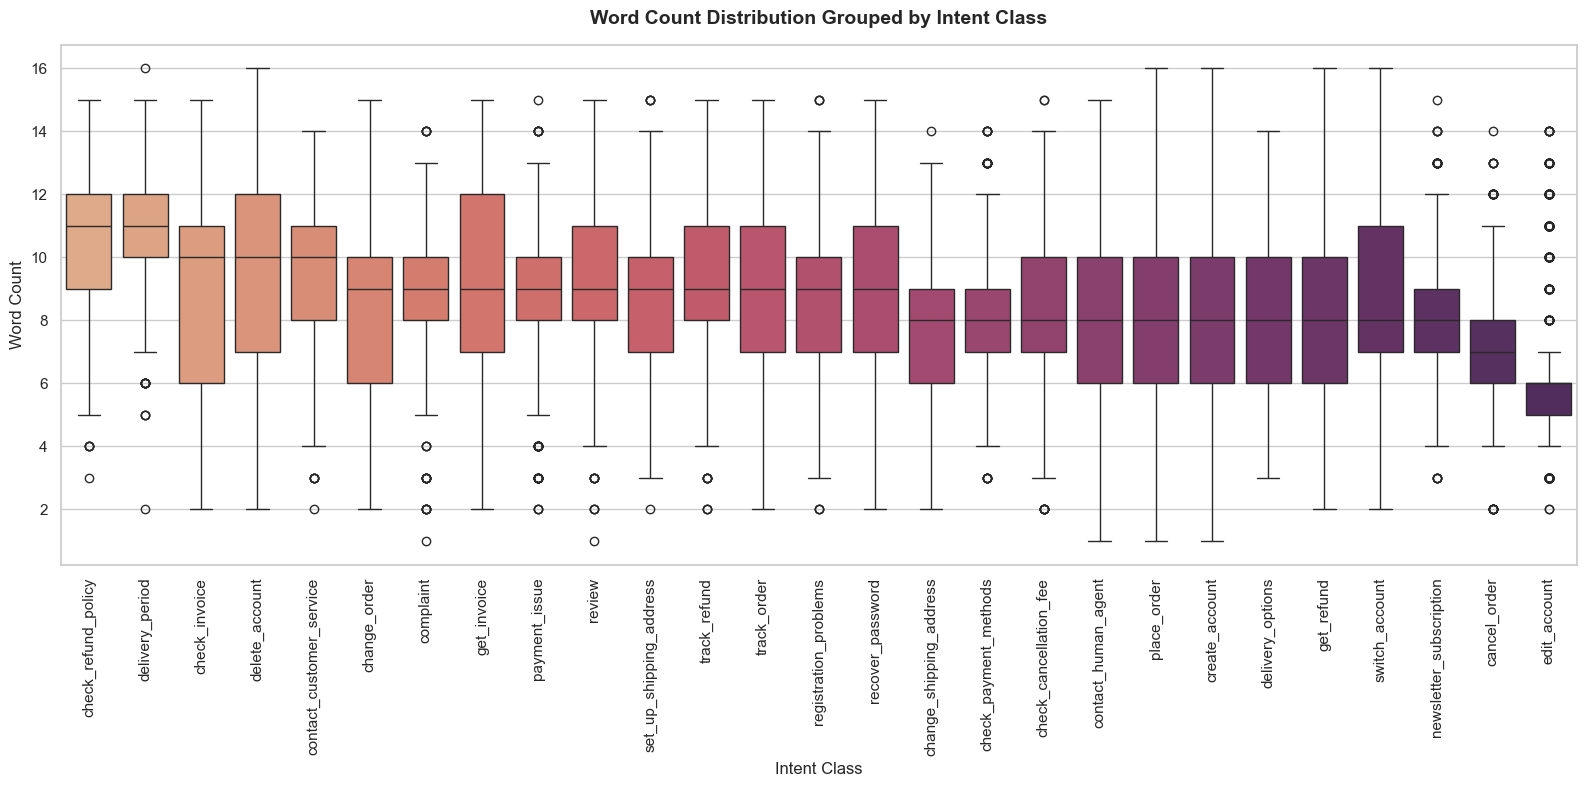

In [6]:
# Add word and character counts
df['word_count'] = df['instruction'].astype(str).apply(lambda x: len(x.split()))
df['char_count'] = df['instruction'].astype(str).apply(len)

print("--- Text Length Summary Statistics ---")
print(df[['word_count', 'char_count']].describe())

# Histograms
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['word_count'], bins=25, kde=True, ax=axes[0], color="royalblue")
axes[0].set_title("Distribution of Word Counts per Query", fontweight="bold")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Frequency")
axes[0].axvline(df['word_count'].mean(), color="red", linestyle="--", label=f"Mean: {df['word_count'].mean():.1f}")
axes[0].axvline(df['word_count'].median(), color="green", linestyle=":", label=f"Median: {df['word_count'].median():.1f}")
axes[0].legend()

sns.histplot(df['char_count'], bins=30, kde=True, ax=axes[1], color="darkcyan")
axes[1].set_title("Distribution of Character Counts per Query", fontweight="bold")
axes[1].set_xlabel("Character Count")
axes[1].set_ylabel("Frequency")
axes[1].axvline(df['char_count'].mean(), color="red", linestyle="--", label=f"Mean: {df['char_count'].mean():.1f}")
axes[1].legend()

plt.tight_layout()
plt.show()

# Boxplot grouped by intent
plt.figure(figsize=(16, 8))
order = df.groupby('intent')['word_count'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='intent', y='word_count', order=order, palette="flare")
plt.xticks(rotation=90)
plt.title("Word Count Distribution Grouped by Intent Class", pad=15, fontweight="bold")
plt.xlabel("Intent Class")
plt.ylabel("Word Count")
plt.tight_layout()
plt.show()


### Commentary: Text Length Analysis
- **Observation:** Average query length is compact (~8-12 words). Queries rarely exceed 25 words.
- **Tokenizer Implication:** For DistilBERT, `max_length=64` or `max_length=128` covers 100% of samples without any truncation, maximizing training throughput.


## 5. Word Clouds

Word clouds highlight the most prominent terms across the global dataset and within specific top intent classes.


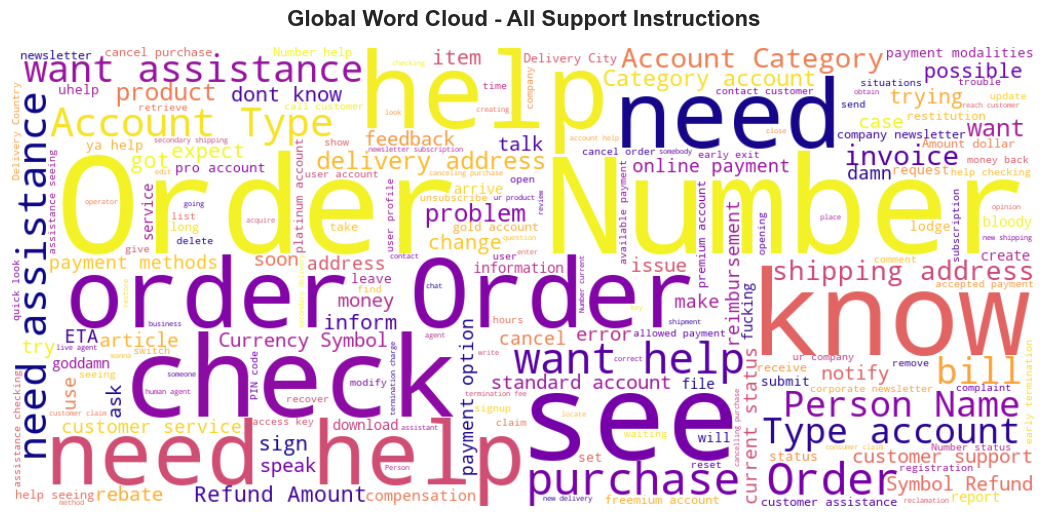

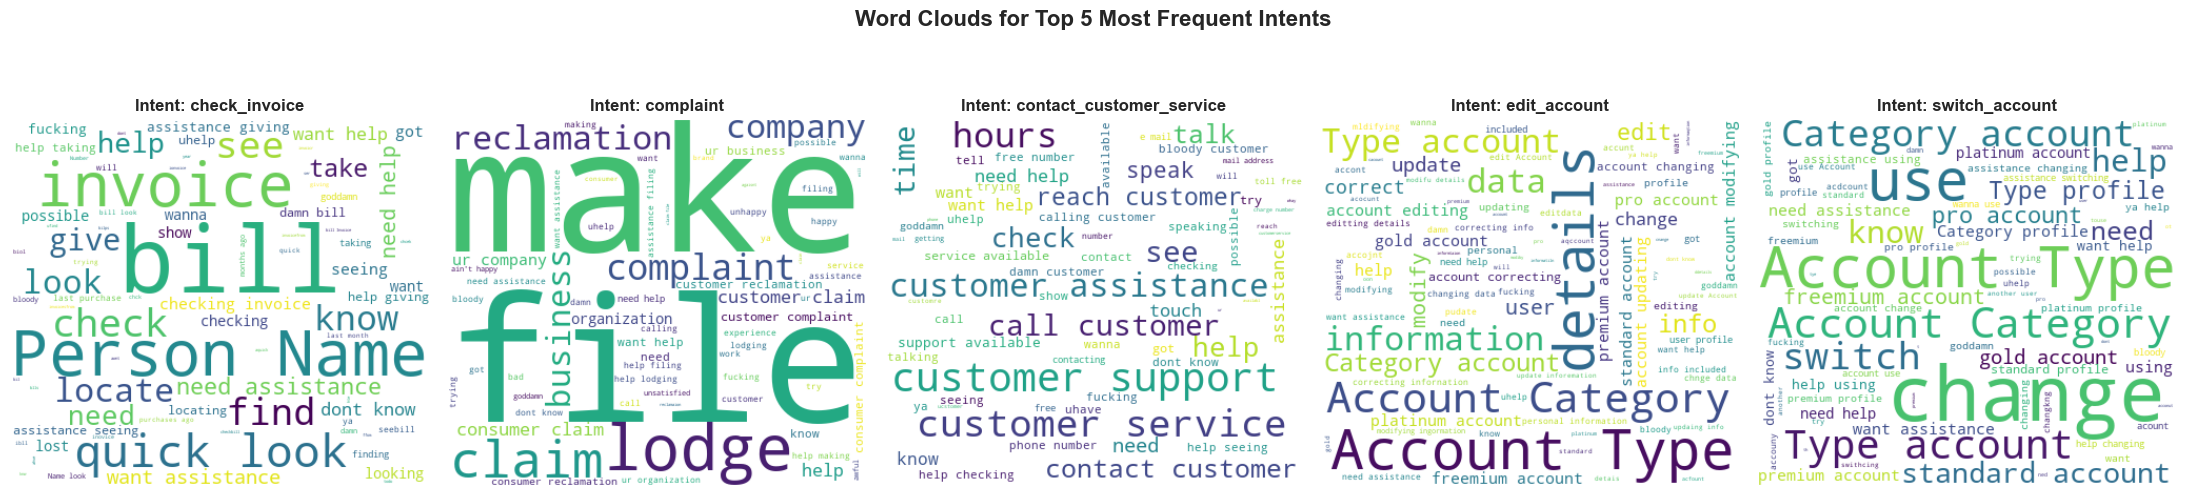

In [7]:
# Global Word Cloud
all_text = " ".join(df['instruction'].dropna())
global_wc = WordCloud(width=1000, height=450, background_color="white", colormap="plasma").generate(all_text)

plt.figure(figsize=(14, 6))
plt.imshow(global_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Global Word Cloud - All Support Instructions", fontsize=16, fontweight="bold", pad=15)
plt.show()

# Word Clouds for Top 5 Intents
top5_intents = df['intent'].value_counts().head(5).index.tolist()

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, intent in zip(axes, top5_intents):
    intent_text = " ".join(df[df['intent'] == intent]['instruction'].dropna())
    wc = WordCloud(width=400, height=350, background_color="white", colormap="viridis").generate(intent_text)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"Intent: {intent}", fontsize=12, fontweight="bold")

plt.suptitle("Word Clouds for Top 5 Most Frequent Intents", fontsize=16, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()


### Commentary: Word Clouds
- **Observation:** Frequent action verbs like "cancel", "track", "order", "change", "refund" provide strong topical anchors for each specific intent.


## 6. N-gram Analysis

Examining the most frequent unigrams, bigrams, and trigrams across the entire corpus and intent-specific bigrams.


C:\Users\111196\AppData\Local\Temp\ipykernel_18864\3806684550.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=unigrams, x="count", y="ngram", ax=axes[0], palette="Blues_r")


C:\Users\111196\AppData\Local\Temp\ipykernel_18864\3806684550.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bigrams, x="count", y="ngram", ax=axes[1], palette="Greens_r")


C:\Users\111196\AppData\Local\Temp\ipykernel_18864\3806684550.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=trigrams, x="count", y="ngram", ax=axes[2], palette="Oranges_r")


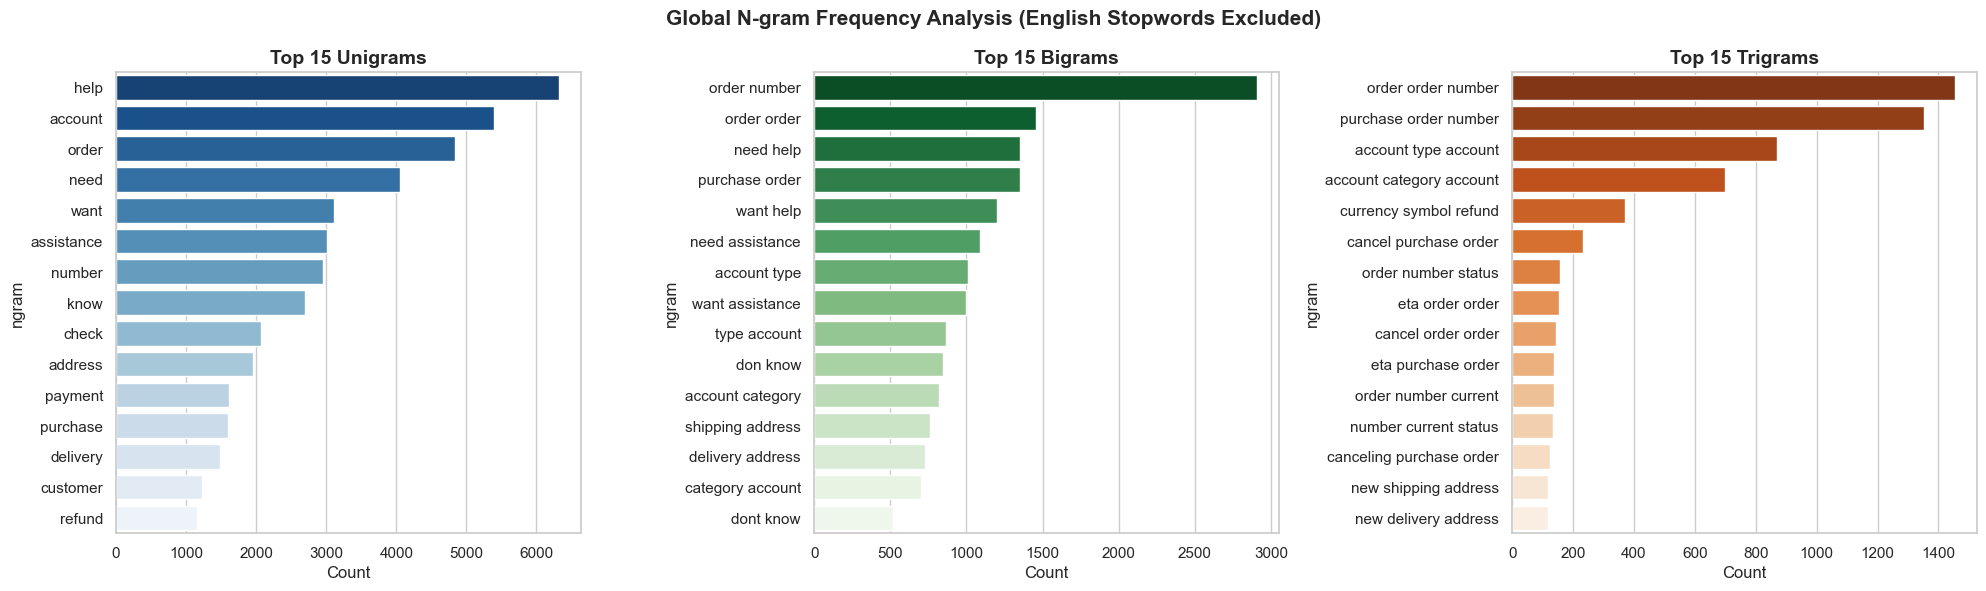

In [8]:
def get_top_ngrams(corpus, n=1, top_k=15):
    vec = CountVectorizer(ngram_range=(n, n), stop_words="english").fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return pd.DataFrame(words_freq[:top_k], columns=["ngram", "count"])

unigrams = get_top_ngrams(df['instruction'], n=1, top_k=15)
bigrams = get_top_ngrams(df['instruction'], n=2, top_k=15)
trigrams = get_top_ngrams(df['instruction'], n=3, top_k=15)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.barplot(data=unigrams, x="count", y="ngram", ax=axes[0], palette="Blues_r")
axes[0].set_title("Top 15 Unigrams", fontweight="bold")
axes[0].set_xlabel("Count")

sns.barplot(data=bigrams, x="count", y="ngram", ax=axes[1], palette="Greens_r")
axes[1].set_title("Top 15 Bigrams", fontweight="bold")
axes[1].set_xlabel("Count")

sns.barplot(data=trigrams, x="count", y="ngram", ax=axes[2], palette="Oranges_r")
axes[2].set_title("Top 15 Trigrams", fontweight="bold")
axes[2].set_xlabel("Count")

plt.suptitle("Global N-gram Frequency Analysis (English Stopwords Excluded)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


C:\Users\111196\AppData\Local\Temp\ipykernel_18864\360916660.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=intent_bigrams, x="count", y="ngram", ax=ax, palette="crest")
C:\Users\111196\AppData\Local\Temp\ipykernel_18864\360916660.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=intent_bigrams, x="count", y="ngram", ax=ax, palette="crest")


C:\Users\111196\AppData\Local\Temp\ipykernel_18864\360916660.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=intent_bigrams, x="count", y="ngram", ax=ax, palette="crest")
C:\Users\111196\AppData\Local\Temp\ipykernel_18864\360916660.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=intent_bigrams, x="count", y="ngram", ax=ax, palette="crest")


C:\Users\111196\AppData\Local\Temp\ipykernel_18864\360916660.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=intent_bigrams, x="count", y="ngram", ax=ax, palette="crest")


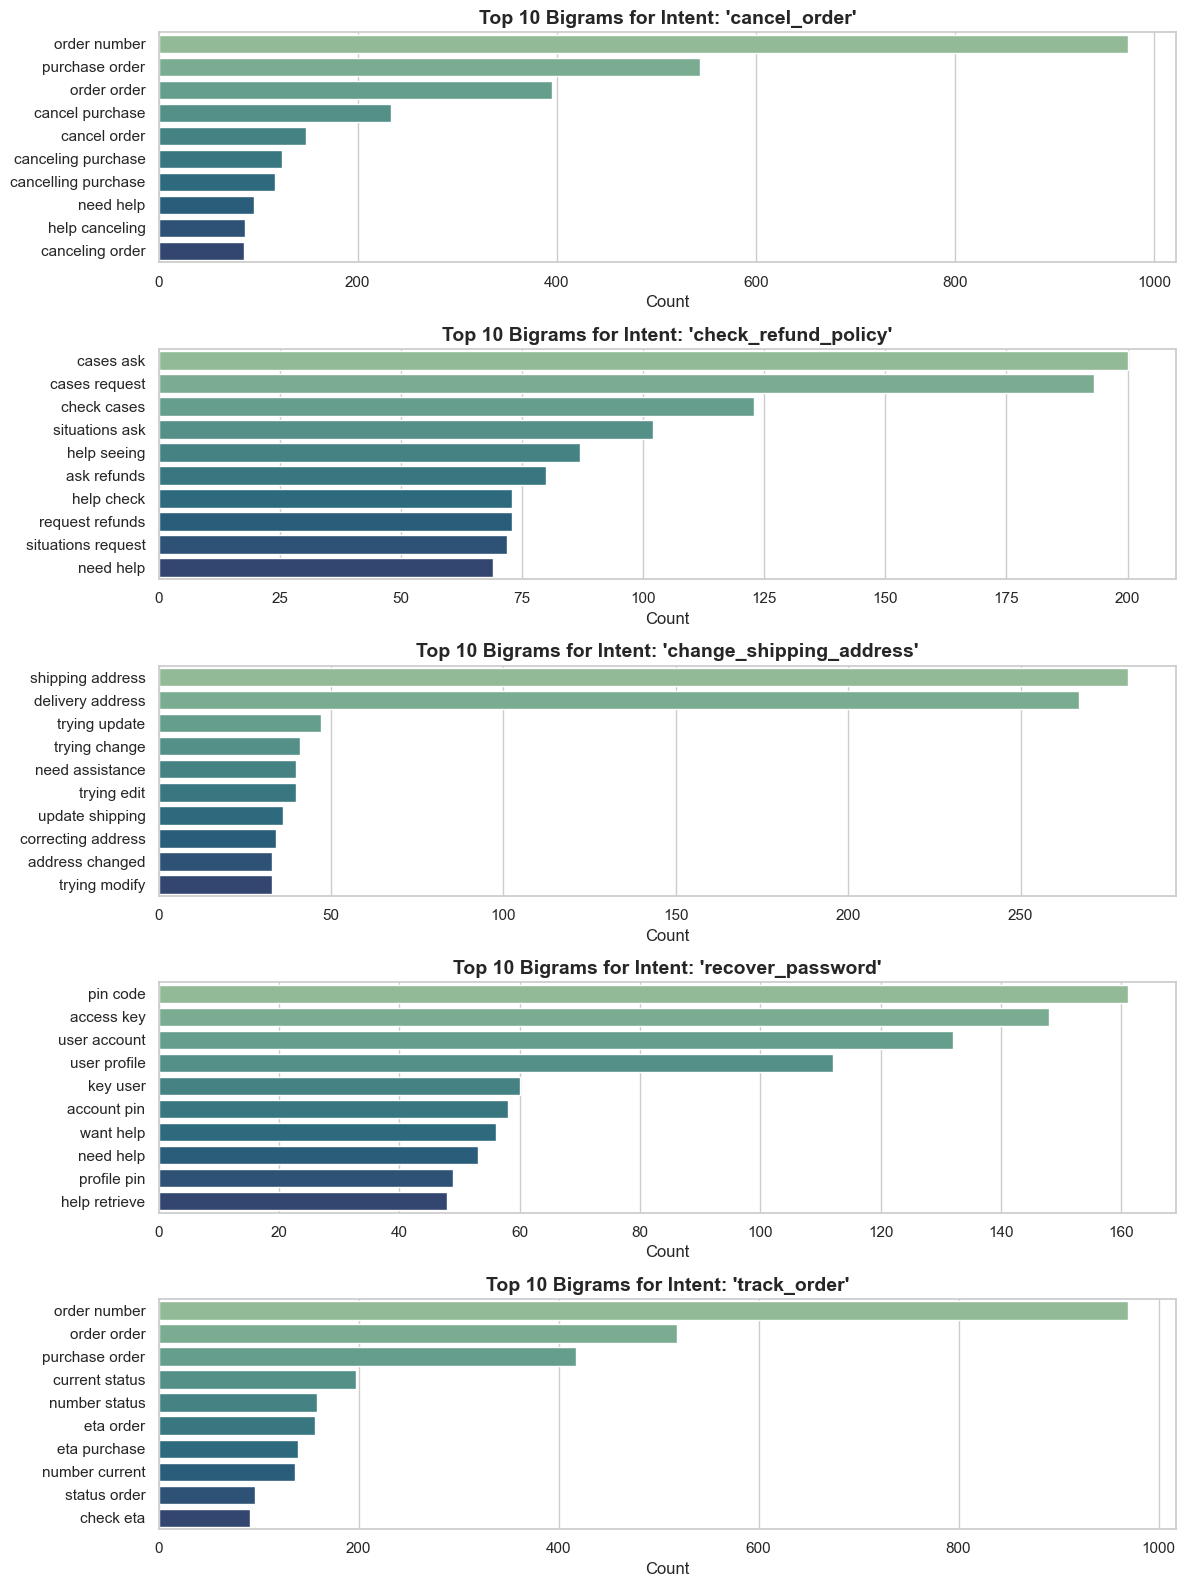

In [9]:
# Top 10 Bigrams for 5 Selected Representative Intents
selected_intents = ["cancel_order", "check_refund_policy", "change_shipping_address", "recover_password", "track_order"]
available_selected = [i for i in selected_intents if i in df['intent'].values]
if len(available_selected) < 5:
    available_selected = df['intent'].value_counts().head(5).index.tolist()

fig, axes = plt.subplots(len(available_selected), 1, figsize=(12, 3.2 * len(available_selected)))
if len(available_selected) == 1:
    axes = [axes]

for ax, intent_name in zip(axes, available_selected):
    subset_corpus = df[df['intent'] == intent_name]['instruction']
    intent_bigrams = get_top_ngrams(subset_corpus, n=2, top_k=10)
    sns.barplot(data=intent_bigrams, x="count", y="ngram", ax=ax, palette="crest")
    ax.set_title(f"Top 10 Bigrams for Intent: '{intent_name}'", fontweight="bold")
    ax.set_xlabel("Count")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()


### Commentary: N-gram Analysis
- **Observation:** Bigrams capture precise intent signatures (e.g., "cancel order", "tracking number", "reset password").
- **Feature Engineering Implications:** Setting `ngram_range=(1, 2)` in TF-IDF will enable the baseline model to capture these crucial phrase boundaries.


## 7. Key Findings & Preprocessing Notes

### 1. Class Imbalance Assessment
- **Status:** The Bitext dataset is balanced across all 27 intent classes (~1,000 instances per class).
- **Implication:** No minority class starvation; standard cross-entropy and accuracy/Macro-F1 metrics are reliable.

### 2. Lexical & Semantic Overlap Across Intents
- Certain intent pairs share considerable vocabulary overlap (e.g. `cancel_order` vs `edit_order`, or `payment_issue` vs `check_invoice`).
- Slot placeholders like `{{Order Number}}` appear across questions. We can preserve these or normalize them so that tokenizers do not treat brackets as arbitrary punctuation noise.

### 3. Recommended Preprocessing Pipeline
1. **Lowercasing & Whitespace stripping:** Standard normalization.
2. **Template Slot Preservation:** Retain or map slot variables (`{{Order Number}}` -> `[ORDER_ID]`).
3. **TF-IDF Vectorizer Configuration:** `ngram_range=(1,2)`, `max_features=10000`, `sublinear_tf=True`.
4. **Transformer Tokenizer:** `distilbert-base-uncased` with `max_length=128`.

### 4. Train / Validation / Test Split Strategy
- **Split Ratio:** Stratified 70% Train / 15% Validation / 15% Test.
- **Fixed Random State:** `random_state=42` to ensure consistent data partitions across TF-IDF, Logistic Regression, and DistilBERT fine-tuning.
